In [1]:
import numpy as np

In [2]:
word_list = [
    "the", "sun", "moon", "sky", "bright", "blue", "hot", "cold",
    "day", "night", "star", "light", "dark", "warm", "cool", "cloud",
    "rain", "wind", "earth", "fire","good", "beautiful"
] #Here we have a words list
vocab =  {}
for i, word in enumerate(word_list):
  vocab[word] = i+1 #created space for <UNK>
vocab["<UNK>"] = 0

In [3]:
def tokens_to_ids(tokens):
    return [vocab.get(token.lower(), vocab["<UNK>"]) for token in tokens]

In [4]:
#Now we introduce embedding mapping the word ids to embedding matriz of size 512
#These are trainable parameters, but are unique to each word
vocab_size = len(vocab)
embedding_dim = 512
#we have created a vector for each and every vocab word.
embedding_matrix = np.random.randn(vocab_size, embedding_dim) * 0.01 #scaling down to prevent exploding gradients

def ids_to_embedding_vector(ids):
  lst = []
  for i in ids:
    if i >= len(embedding_matrix):
      i = vocab["<UNK>"]
      lst.append(embedding_matrix[i])
    if len(lst) == 0:
      lst.append(np.zeros(embedding_dim))
  return np.array(lst)


Here is the formulas used in "Attention is all you need" paper

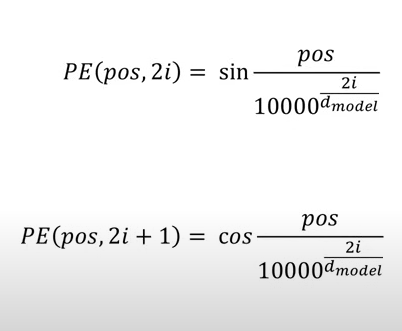

In [5]:
def positional_encoding(length_seq, dim_model=512):
  pos = np.arange(length_seq)[:, np.newaxis] #shape (seq_len, 1)
  i = np.arange(dim_model)[np.newaxis,:] #shape (1,dim_model)
  pe = pos / (10000**(i/dim_model)) #positional encoding

  #now apply cos to odd and sin to even
  pe[:, 0::2] = np.sin(pe[:, 0::2])
  pe[:,1::2] = np.cos(pe[:,1::2])
  return pe

In [6]:
def embeddings_with_pe(embeddings, pe):
  return embeddings + pe

Now time for masked_multi_head_attention() and some helper functions like softmax().
Here are some formulae used:

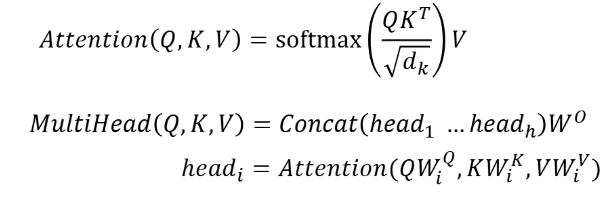

In [7]:
#In attention, we want each query to decide how much to focus on each key/value.
#softmax turns the scores for all keys (for this query) into weights that sum to 1.
def softmax(x):
  e_x = np.exp(x - np.max(x,axis=-1, keepdims=True)) # max is used for numerical stability
  return e_x / np.sum(e_x, axis=-1, keepdims=True)

In [8]:
def split_heads(x, num_heads):
  seq_len, embedding_dim = x.shape
  depth = embedding_dim//num_heads #dividing x into num_heads heads
  return np.reshape(x, (seq_len, depth, num_heads))

In [9]:
def masked_multi_head_attention(embeddings, num_heads=4):
  seq_length, embedding_dim = embeddings.shape
  depth = embedding_dim//num_heads

  #Initialize the random weight matrices for Q,K,V
  Wq = np.random.randn(embedding_dim, embedding_dim) * 0.01
  Wk = np.random.randn(embedding_dim, embedding_dim) * 0.01
  Wv = np.random.randn(embedding_dim, embedding_dim) * 0.01

  #Now compute Q, K,V
  Q = np.dot(embeddings, Wq)  # (seq_len, embedding_dim)
  K = np.dot(embeddings, Wk)  # (seq_len, embedding_dim)
  V = np.dot(embeddings, Wv)  # (seq_len, embedding_dim)

  # Split into heads
  Q_heads = split_heads(Q, num_heads)
  K_heads = split_heads(K, num_heads)
  V_heads = split_heads(V, num_heads)

  # Now apply attention to all heads
  attention_heads=[]
  for i in range(num_heads):
    q = Q_heads[:,:,i] # (seq_len, depth)
    k = K_heads[:,:,i]
    v = V_heads[:,:,i]
    scores = np.dot(q, k.T) / np.sqrt(depth)
    mask = np.triu(np.ones((seq_length, seq_length)), k=1) * -1e9 #this ensures that each token can only attend to itself and previous tokens
    scores += mask
    weights = softmax(scores)
    output = np.dot(weights, v) # (seq_len, depth)
    attention_heads.append(output)

  #Concatenate heads along depth axis
  concat = np.concatenate(attention_heads, axis=1) # (seq_len, embedding_dim)
  return concat


Layer Normalization normalizes all features for a single data point

Batch Normalization normalizes a single feature across all data points in the batch.


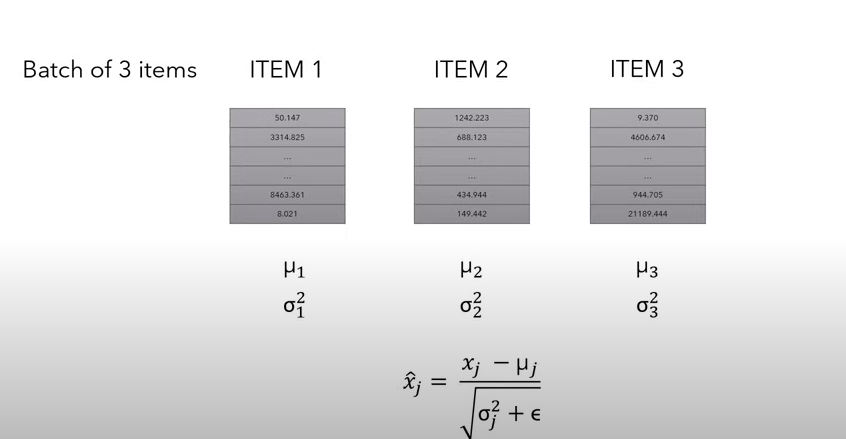


In [10]:
def layer_norm(x, gamma=None, beta=None, exp=1e-6):
  mean  = np.mean(x, axis=-1, keepdims = True)
  vr = np.var(x, axis = -1, keepdims = True)
  x_hat = (x-mean)/np.sqrt(vr**2+exp)
  #Without gamma and beta, LayerNorm always forces zero mean and unit variance
  if gamma is not None:
    x_hat = x_hat * gamma
  if beta is not None:
    x_hat = x_hat + beta
  return x_hat

In [11]:
# We now create a 2 layer feedfoward neural network
#Following the standard Transformer architecture, we set the hidden dimension to 2048, which is 4× the embedding size.(mentioned in the paper)

def feed_forward(x, hidden_dim=2048):
  seq_len, embedding_dim = x.shape

  # Initialize weights and biases
  W1 = np.random.randn(embedding_dim, hidden_dim) * 0.01
  b1 = np.zeros((hidden_dim,))
  W2 = np.random.randn(hidden_dim, embedding_dim) * 0.01
  b2 = np.zeros((embedding_dim,))

  # First linear + ReLU
  hidden = np.maximum(0, np.dot(x, W1) + b1)

  # LayerNorm with gamma and beta
  gamma = np.ones((hidden_dim,))
  beta = np.zeros((hidden_dim,))
  hidden = layer_norm(hidden, gamma, beta)

  out = np.dot(hidden, W2) + b2

  return out


In [12]:
# Now time for decoder block
def decoder_block(x):
  attn_out = masked_multi_head_attention(x)
  x = layer_norm(x + attn_out)
  ff_output = feed_forward(x)
  x = layer_norm(x + ff_output)
  return x

In [13]:

def decode_only_transformer(input_ids):
  embeddings = ids_to_embedding_vector(input_ids)
  seq_len = embeddings.shape[0]
  pe = positional_encoding(seq_len, embedding_dim)
  x = embeddings_with_pe(embeddings, pe)
  x = decoder_block(x)
  W = np.random.randn(embedding_dim, vocab_size) * 0.01
  output = softmax(np.dot(x, W)) #produces a probability vector for each token position. W is used to change x to (seq_len, vocab_size)
  return output

In [14]:
id_to_word = {i: word for word, i in vocab.items()} #to extract word from id

def predict_next_word(sentence):
  tokens = sentence.split()
  ids = tokens_to_ids(tokens)
  probs = decode_only_transformer(ids)
  next_word_id = np.argmax(probs) #return id with highest probs
  return id_to_word.get(next_word_id, "<UNK>")

In [15]:
print("Example 1: The sun is: \n")
print("Prediction:", predict_next_word("The sun is"))
print("\nExample 2: This is very")
print("Prediction:", predict_next_word("This is very"))

Example 1: The sun is: 

Prediction: good

Example 2: This is very
Prediction: sun


Now lets train our model

In [16]:
train_texts = [
    "the sun is bright",
    "the sun is hot",
    "the moon is bright",
    "the stars shine",
    "the night is dark",
    "the day is warm",
    "the sky is blue",
    "the grass is green",
    "the ocean is deep",
    "the earth is round",
    "This is amazing",
    "This is extremely good",
    "The sun is above",
    "This looks deep"
]

In [17]:
#now we tokenize the words
train_ids = []
for line in train_texts:
  tokens = line.split()
  ids = tokens_to_ids(tokens)
  train_ids.append(ids)

In [18]:
lr = 0.001
epochs = 10

In [19]:
# Initialize output weight W
W = np.random.randn(embedding_dim, vocab_size) * 0.01

In [20]:
for epoch in range(epochs):
  total_loss = 0
  for ids in train_ids:
    if len(ids) < 2:
      continue
    input_ids = ids[:-1]
    target_id = ids[-1]

    embeddings = ids_to_embedding_vector(input_ids)
    if embeddings.shape[0] == 0:
      continue
    pe = positional_encoding(embeddings.shape[0], embedding_dim)
    x = embeddings_with_pe(embeddings, pe)

    # Forward
    attention_out = masked_multi_head_attention(x, num_heads=4)
    x = layer_norm(x + attention_out)
    ff_out = feed_forward(x)
    x = layer_norm(x + ff_out)
    # Prediction
    scores = np.dot(x[-1], W)
    probs = softmax(scores)
    if np.any(np.isnan(probs)) or target_id >= probs.shape[0]:
        continue

    # Loss
    loss = -np.log(probs[target_id] + 1e-9)
    total_loss += loss

    # Backprop (update W only)
    grad_scores = probs
    grad_scores[target_id] -= 1
    grad_W = np.outer(x[-1], grad_scores)
    W -= lr * grad_W

  print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.2f}")

print("Complete")


Epoch 1/10, Loss: 43.19
Epoch 2/10, Loss: 41.52
Epoch 3/10, Loss: 39.77
Epoch 4/10, Loss: 38.13
Epoch 5/10, Loss: 36.57
Epoch 6/10, Loss: 35.90
Epoch 7/10, Loss: 34.64
Epoch 8/10, Loss: 33.20
Epoch 9/10, Loss: 32.95
Epoch 10/10, Loss: 31.60
Complete


In [21]:
def predict_next_word(sentence):
  tokens = sentence.split()
  ids = tokens_to_ids(tokens)

  if len(ids) == 0:
      return "<UNK>"

  embeddings = ids_to_embedding_vector(ids)
  pe = positional_encoding(embeddings.shape[0], embedding_dim)
  x = embeddings_with_pe(embeddings, pe)

  attention_out = masked_multi_head_attention(x, num_heads=4)
  x = layer_norm(x + attention_out)
  ff_out = feed_forward(x)
  x = layer_norm(x + ff_out)

  scores = np.dot(x[-1], W)  # last token's state
  probs = softmax(scores)

  next_word_id = np.argmax(probs)
  return id_to_word.get(next_word_id, "<UNK>")


In [22]:
print("Example 1: The sun is: \n")
print("Prediction:", predict_next_word("The sun is"))
print("\nExample 2: This is very")
print("Prediction:", predict_next_word("This is very"))

Example 1: The sun is: 

Prediction: <UNK>

Example 2: This is very
Prediction: <UNK>


Here is a code for word embeddings representation

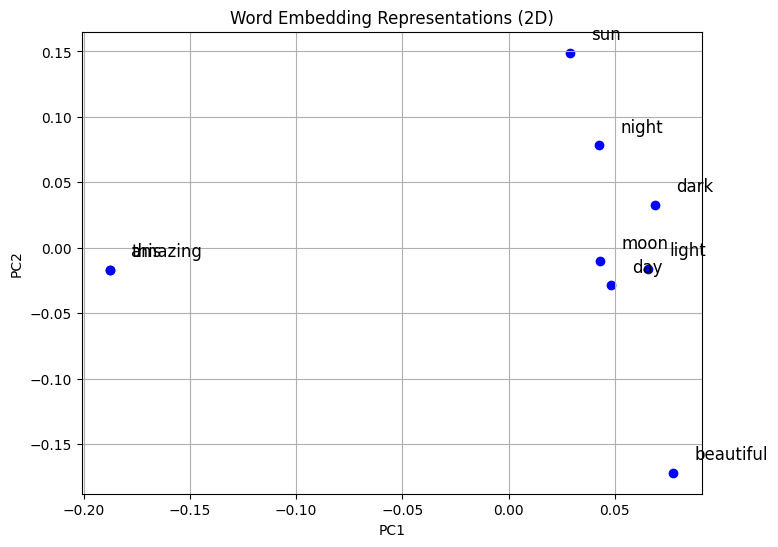

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words_to_plot = ["sun", "moon", "day", "night", "light", "dark", "this", "amazing", "beautiful"]

embs = []
for word in words_to_plot:
    idx = vocab.get(word, 0)
    embs.append(embedding_matrix[idx])
embs = np.array(embs)  # shape: (num_words, embedding_dim)

# Reduce to 2D
pca = PCA(n_components=2)
embs_2d = pca.fit_transform(embs)

# Plot
plt.figure(figsize=(8,6))
for i, word in enumerate(words_to_plot):
    x, y = embs_2d[i]
    plt.scatter(x, y, color='blue')
    plt.text(x+0.01, y+0.01, word, fontsize=12)
plt.title("Word Embedding Representations (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


From the 2D plot, we can see that semantically related words like sun, light, moon, day, night, dark are roughly clustered together, while more abstract or less frequent words like amazing, this, beautiful are positioned farther apart. This indicates that the model has learned some basic relationships in the embedding space.

For improvement, using a larger and more diverse vocabulary, training on more data, and adding deeper layers or contextual embeddings could help the model capture richer semantic relationships.

We can improve by adding learnable Wq, Wk, Wv for attention, layer normalization with gamma and beta, and training all parameters including embeddings and output weights.